Datasets used:
 - DCP building dataset(https://github.com/pcm-dpc/DPC-Aggregati-Strutturali-ITG-Isole)
 - GHSL dataset for net height and characteristics (https://human-settlement.emergency.copernicus.eu/download.php?ds=builtH)
 - ESRM Building Cost Info (https://gitlab.seismo.ethz.ch/efehr/esrm20_exposure/-/blob/master/sources/European_Exposure_Model_Data_Inputs_Sources.xlsx)

<AxesSubplot: >

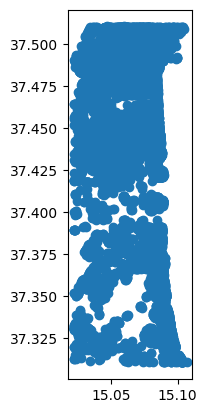

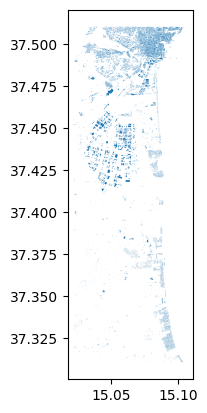

In [22]:
import os
import sys
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#read geopackage file with building polygons
file_path = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/exposure/CT_Building_Footprint.gpkg'
buildings_footprint = gpd.read_file(file_path, driver='GPKG', layer='Building_Footprint')
buildings_attributes = gpd.read_file(file_path, driver='GPKG', layer='Building_Attributes')

# buildings_footprint.columns
# Index(['IDAG', 'Label', 'Comune', 'layer', 'path', 'PlinthArea', 'geometry'], dtype='object')

# buildings_attributes.columns
# Index(['IDAG', 'CT_DSM', 'GHSL_C_wgs', 'GHSL_NH_wg', 'DCP_Buildi',
#        'DCP_Buil_1', 'DCP_Buil_2', 'DCP_Buil_3', 'DCP_Buil_4', 'DCP_Buil_5',
#        'DCP_Buil_6', 'geometry'],
#       dtype='object')

#rename columns
buildings_attributes.columns = ['IDAG', 'Elevation', 'GHSL_C','GHSL_NH', 'ID', 'Comune', 'layer', 'path', 'PlinthArea', 'Lat','Lon','Flooded','geometry']
buildings_attributes.head()


# plot the building centroids and footprints
buildings_attributes.plot()
buildings_footprint.plot()


Unit Costs of Construction from ESRM for Italy:
 - Residential
    - 1300 Euro/m^2 (Big City)
    - 1000 Euro/m^2 (Urban)
    - 900 Euro/m^2 (Rural)
- Commercial
    - 1400 Euro/m^2 (Office)
    - 1050 Euro/m^2 (Trade)
    - 1470 Euro/m^2 (Hotel)
- Industrial
    - 700 Euro/m^2 (Light)

Building value = plint area(sq m) * unit cost (Euro/sq m) * nFloors

    
    


In [23]:
#if flooded not 1 set as 0
buildings_attributes['Flooded'] = np.where(buildings_attributes['Flooded'] != 1, 0, buildings_attributes['Flooded'])

#Asign nFloors based on net height
#  < 4.5m - 1 floor
# 4.5 - 7m - 2 floors
# > 7 m - round down(net height / 3)
buildings_attributes['nFloors'] = np.where(buildings_attributes['GHSL_NH'] < 4.5, 1, 0)
buildings_attributes['nFloors'] = np.where(buildings_attributes['GHSL_NH'] >= 4.5, 2, buildings_attributes['nFloors'])
buildings_attributes['nFloors'] = np.where(buildings_attributes['GHSL_NH'] > 7, np.floor(buildings_attributes['GHSL_NH'] / 3), buildings_attributes['nFloors'])
#set nFloors to int
buildings_attributes['nFloors'] = buildings_attributes['nFloors'].astype(int)

# Occupancy type = residential(1), non-residential(2), other (0)
buildings_attributes['Occupancy'] = np.where(buildings_attributes['GHSL_C'] == 1, 'R', 'C')
buildings_attributes['Occupancy'] = np.where(buildings_attributes['GHSL_C'] == 0, 'I', buildings_attributes['Occupancy'])

#Reconstruction cost based on ESRM2020
I_unitcost = 700
R_unitcost = 1000
C_unitcost = 1400

buildings_attributes['Value'] = np.where(buildings_attributes['Occupancy'] == 'R', buildings_attributes['PlinthArea'] * buildings_attributes['nFloors'] * R_unitcost, 0)
buildings_attributes['Value'] = np.where(buildings_attributes['Occupancy'] == 'C', buildings_attributes['PlinthArea'] * buildings_attributes['nFloors'] * C_unitcost, buildings_attributes['Value'])
buildings_attributes['Value'] = np.where(buildings_attributes['Occupancy'] == 'I', buildings_attributes['PlinthArea'] * buildings_attributes['nFloors'] * I_unitcost, buildings_attributes['Value'])

# Assign Construction type as RC or M as random when LR and MR upto 5 floors, HR only RC
buildings_attributes['Construction'] = np.where(np.random.rand(len(buildings_attributes)) > 0.5, 'RC', 'M')
buildings_attributes['Construction'] = np.where(buildings_attributes['nFloors'] > 5, 'RC', buildings_attributes['Construction'])

# Assign building floor type based on number of floors
# For RC type:(LR)low-rise buildings 1-3 or (MR) mid-rise buildings 3-5 storeys
# For Masonary type:(LR) low-rise with 1-2 storeys or (MR) mid-rise with 4-6 storeys or (HR) high-rise with greater than 6 storeys
buildings_attributes['FloorType'] = 'HR'
buildings_attributes['FloorType'] = np.where((buildings_attributes['nFloors'] < 7) & (buildings_attributes['Construction'] == 'RC'), 'MR', buildings_attributes['FloorType'])
buildings_attributes['FloorType'] = np.where((buildings_attributes['nFloors'] < 4) & (buildings_attributes['Construction'] == 'RC'), 'LR', buildings_attributes['FloorType'])
buildings_attributes['FloorType'] = np.where((buildings_attributes['nFloors'] < 6) & (buildings_attributes['Construction'] == 'M'), 'MR', buildings_attributes['FloorType'])
buildings_attributes['FloorType'] = np.where((buildings_attributes['nFloors'] < 2) & (buildings_attributes['Construction'] == 'M'), 'LR', buildings_attributes['FloorType'])

# Building Class(Construction type + number of floors)
buildings_attributes['Building_Class'] = buildings_attributes['Construction'].astype(str) + '_' + buildings_attributes['FloorType'].astype(str)


In [24]:
test = buildings_attributes[buildings_attributes['nFloors']>7]
test.tail()

,IDAG,Elevation,GHSL_C,GHSL_NH,ID,Comune,layer,path,PlinthArea,Lat,Lon,Flooded,geometry,nFloors,Occupancy,Value,Construction,FloorType,Building_Class
10443,19087015000001657000,37.67714,2.0,31.00973,16570,Catania,Catania,C:/Users/Naveen/Downloads/Exposure_Chapter/Sic...,336,37.479949,15.052676,0.0,POINT (15.05268 37.47995),10,C,4704000,RC,HR,RC_HR
10445,19087015000001657200,36.30774,2.0,32.67207,16572,Catania,Catania,C:/Users/Naveen/Downloads/Exposure_Chapter/Sic...,1083,37.481311,15.055171,0.0,POINT (15.05517 37.48131),10,C,15162000,RC,HR,RC_HR
12146,19087015000001834300,36.07634,2.0,34.71394,18343,Catania,Catania,C:/Users/Naveen/Downloads/Exposure_Chapter/Sic...,507,37.479823,15.055252,0.0,POINT (15.05525 37.47982),11,C,7807800,RC,HR,RC_HR
12147,19087015000001834400,38.52914,2.0,32.67207,18344,Catania,Catania,C:/Users/Naveen/Downloads/Exposure_Chapter/Sic...,3342,37.480780,15.055809,0.0,POINT (15.05581 37.48078),10,C,46788000,RC,HR,RC_HR
12148,19087015000001834500,37.99914,2.0,32.67207,18345,Catania,Catania,C:/Users/Naveen/Downloads/Exposure_Chapter/Sic...,881,37.481315,15.055686,0.0,POINT (15.05569 37.48131),10,C,12334000,RC,HR,RC_HR


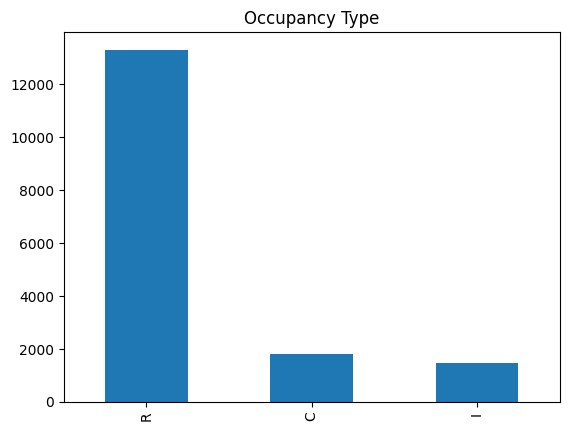

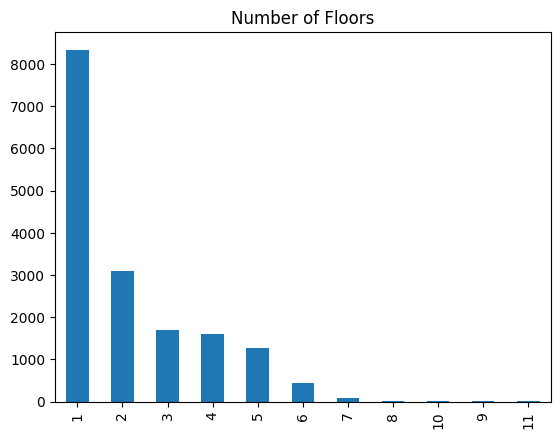

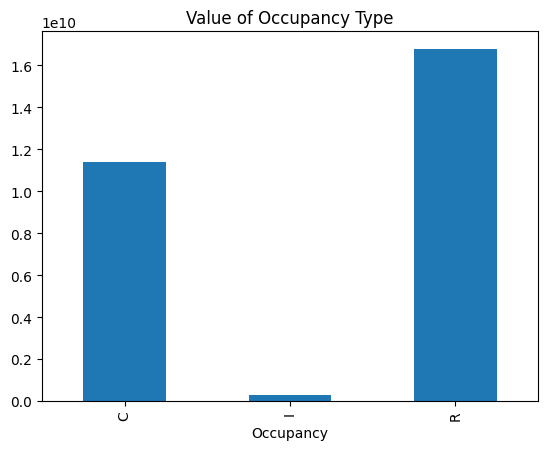

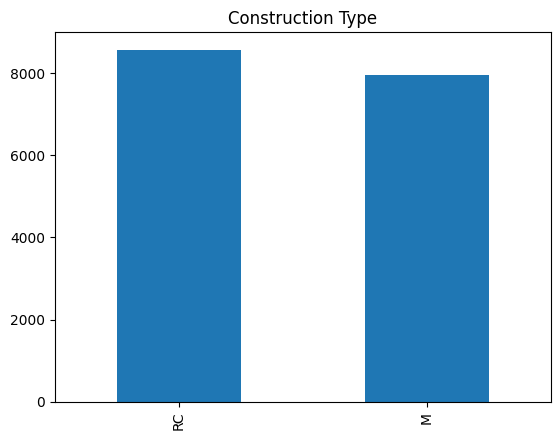

Total Buildings:
 16,538

Buildings by Class:
 RC_LR    6543
M_LR     4162
M_MR     3804
RC_MR    1936
RC_HR      93
Name: Building_Class, dtype: int64

Building if flooded:
 1.0    9363
0.0    7175
Name: Flooded, dtype: int64

Total Value:
 28,491,684,200

Total Value by Occupancy:
 Occupancy
C    11404614200
I      300181000
R    16786889000
Name: Value, dtype: int64

Total Value by Flooded:
 Flooded
0.0    20292155800
1.0     8199528400
Name: Value, dtype: int64



In [25]:
import matplotlib.pyplot as plt
#plot distribution of buildings

#by occupancy
buildings_attributes['Occupancy'].value_counts().plot(kind='bar')
plt.title('Occupancy Type')
plt.show()

#by number of floors
buildings_attributes['nFloors'].value_counts().plot(kind='bar')
plt.title('Number of Floors')
plt.show()

#by value of occupancy type
buildings_attributes.groupby('Occupancy')['Value'].sum().plot(kind='bar')
plt.title('Value of Occupancy Type')
plt.show()

#by construction type
buildings_attributes['Construction'].value_counts().plot(kind='bar')
plt.title('Construction Type')
plt.show()


#counts of buildings by class
print(f"Total Buildings:\n {len(buildings_attributes):,}\n")
print(f"Buildings by Class:\n {buildings_attributes['Building_Class'].value_counts()}\n")   
print(f"Building if flooded:\n {buildings_attributes['Flooded'].value_counts()}\n")


#total value
print(f"Total Value:\n {buildings_attributes['Value'].sum():,}\n")
#total value by occupancy
print(f"Total Value by Occupancy:\n {buildings_attributes.groupby('Occupancy')['Value'].sum()}\n")
#total value by flooded or not
print(f"Total Value by Flooded:\n {buildings_attributes.groupby('Flooded')['Value'].sum()}\n")



In [26]:
# drop path and layer columns
buildings_attributes.drop(['path', 'layer'], axis=1, inplace=True)

# add to existing gpkg
buildings_attributes.to_file(file_path, driver='GPKG', layer='Building_ExposureInfo', append=True)

#modify for openquake input
# {'id', 'lat', 'value-number', 'lon', 'Value', 'occupants_night', 'taxonomy'}
#rename IDAG to id,Lon to lon, Lat to lat, class to taxonomy
#set occupants_night to 0
buildings_attributes['Occupants_Night'] = 0
buildings_attributes['Buildings'] = 1

#write to csv
buildings_attributes.to_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/loss/building_exposure.csv', index=False)